# Exploratory Visual Analysis (EDA)

EDA is the phase where you play detective. You don't have a specific hypothesis yet; you are simply asking the data to reveal its secrets. 

When visualizing data for exploration, we generally look for three things:
1. **Distributions**: What is the "shape" of a single column?
2. **Relationships**: How do two continuous numbers interact with each other?
3. **Comparisons**: How do different categories stack up against each other?

Let's set up a Python sandbox with a realistic Real Estate dataset to practice our visual interrogation skills.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create a realistic housing dataset
np.random.seed(42)

# Generate 500 houses
sqft = np.random.normal(2000, 500, 500)
neighborhoods = np.random.choice(['Downtown', 'Suburbs', 'Rural'], 500, p=[0.2, 0.5, 0.3])

# Calculate price based on size and neighborhood
base_price = sqft * 150
multiplier = {'Downtown': 1.5, 'Suburbs': 1.0, 'Rural': 0.7}
price = base_price * [multiplier[n] for n in neighborhoods] + np.random.normal(0, 50000, 500)

df = pd.DataFrame({
    'Neighborhood': neighborhoods,
    'SqFt': sqft,
    'Price': price
})

# Set the default Seaborn theme for beautiful EDA charts
sns.set_theme(style="whitegrid")

print("✅ Real Estate Dataset loaded!")
display(df.head())

✅ Real Estate Dataset loaded!


,Neighborhood,SqFt,Price
0,Suburbs,2248.357077,328897.657460
1,Suburbs,1930.867849,296965.861734
2,Suburbs,2323.844269,408902.088683
3,Rural,2761.514928,249112.283912
4,Suburbs,1882.923313,300872.162339


# 1. Visualizing Distributions (Histograms & KDEs)
The very first question you should ask about any numerical column is: *"What is its shape?"* Is it perfectly symmetrical? Is it heavily skewed to the right by millionaires? 

We answer this using a **Histogram**, which chops the data into bins and counts how many rows fall into each bin. We often overlay a **KDE (Kernel Density Estimate)**, which is a smooth curve that represents the overall shape of the data.

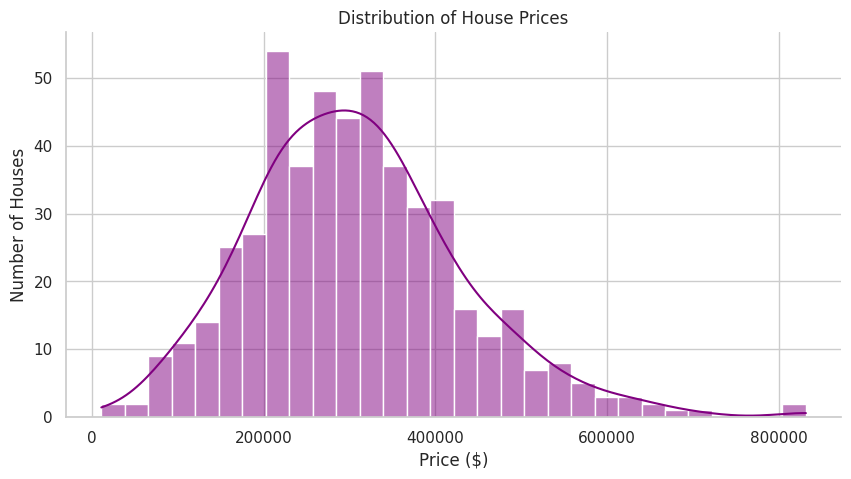

In [2]:
plt.figure(figsize=(10, 5))

# Plot the distribution of house prices
sns.histplot(data=df, x='Price', bins=30, kde=True, color='purple')

plt.title('Distribution of House Prices')
plt.xlabel('Price ($)')
plt.ylabel('Number of Houses')

# Removing top and right spines to reduce noise
sns.despine()

plt.show()

*(When you look at this chart, you immediately understand the "average" house price, and you can visually spot if there are any massive outliers dragging the tail to the right!)*

# 2. Visualizing Relationships (Scatterplots)
Once you understand individual columns, you want to see how two continuous variables affect each other. Does increasing the Square Footage actually increase the Price?

We use a **Scatterplot** to plot every single row as a dot on an X/Y axis.

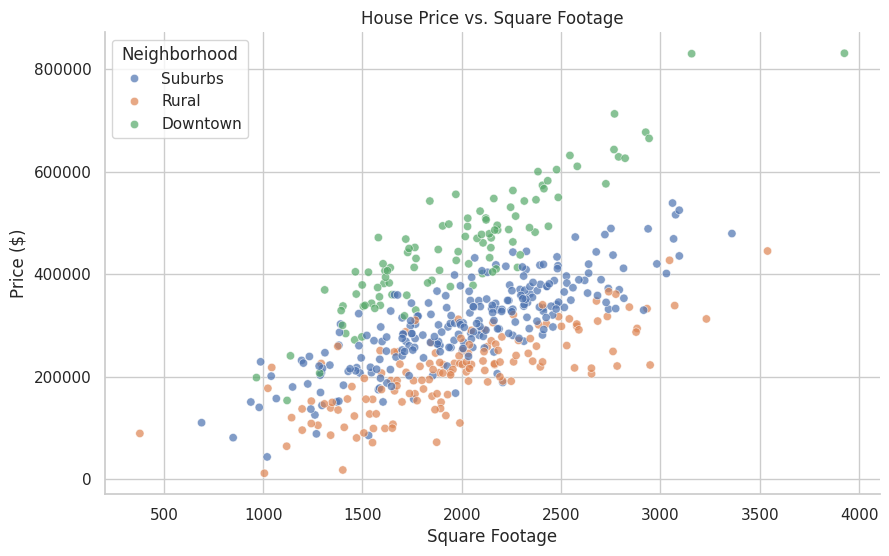

In [3]:
plt.figure(figsize=(10, 6))

# Plot SqFt vs Price, and color the dots by Neighborhood!
sns.scatterplot(data=df, x='SqFt', y='Price', hue='Neighborhood', alpha=0.7, palette='deep')

plt.title('House Price vs. Square Footage')
plt.xlabel('Square Footage')
plt.ylabel('Price ($)')
sns.despine()

plt.show()

*(By adding the `hue='Neighborhood'` parameter, we instantly added a third dimension to our chart. We can clearly see three distinct "tracks" of data. A 2,000 sqft house in Downtown is vastly more expensive than a 2,000 sqft house in a Rural area!)*

# 3. Visualizing Comparisons (Boxplots)
Scatterplots are great for comparing two numbers. But what if you want to compare a Number (Price) against a Category (Neighborhood)?

We use a **Boxplot**. A boxplot visually represents the exact same IQR (Interquartile Range) math we learned back in Section 5 when dealing with Outliers.
* The **Box** represents the middle 50% of the data.
* The **Line in the middle** is the Median.
* The **Whiskers** show the normal range of the data.
* The **Individual Dots** on the edges are mathematically flagged outliers!

/tmp/ipykernel_10918/2593123175.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Neighborhood', y='Price', palette='Set2')


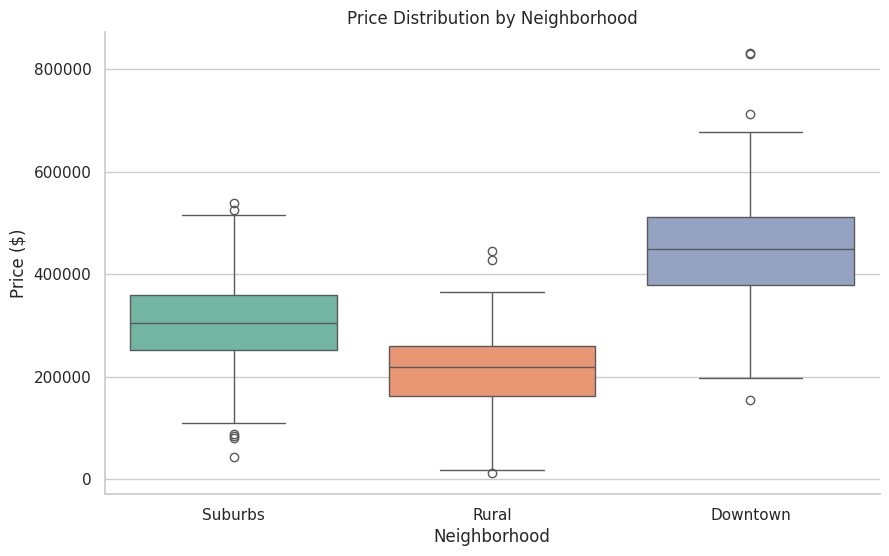

In [4]:
plt.figure(figsize=(10, 6))

# Compare Prices across the three Neighborhoods
sns.boxplot(data=df, x='Neighborhood', y='Price', palette='Set2')

plt.title('Price Distribution by Neighborhood')
plt.ylabel('Price ($)')
sns.despine()

plt.show()

*(Boxplots are the ultimate EDA tool for executives. In one glance, you can see that Downtown has the highest median price, the widest variance (tallest box), and a few massive outliers at the very top!)*

# 4. The Data Scientist's Multi-Tool (Pairplot)
When you have a dataset with 10 different numerical columns, typing out code for every single combination of scatterplots and histograms takes forever. 

Seaborn provides an EDA cheat code: the **Pairplot**. It automatically takes every single numerical column in your dataset and plots them against each other in a massive grid.

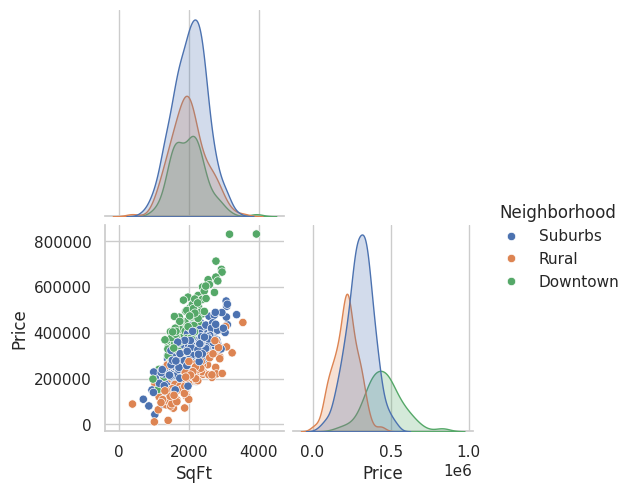

In [5]:
# Create a pairplot for the entire dataframe
# We color it by Neighborhood to see how the categories split the data
sns.pairplot(df, hue='Neighborhood', palette='deep', corner=True)

# Note: corner=True removes the duplicate charts on the top right half of the grid!
plt.show()

## Real-World Use Case or Analogy:
Think of Exploratory Visual Analysis like a **Medical MRI Scan**:

* **The Problem**: A patient (the dataset) comes in complaining of pain. You have no idea what is wrong. If you just immediately prescribe surgery (Machine Learning), you might cut out the wrong organ.
* **Distributions (The Vitals)**: You check their heart rate and blood pressure against a standard curve. Are they in the normal range, or is their heart rate heavily skewed?
* **Comparisons (The Chart History)**: You look at a Boxplot of their blood sugar over the last four weeks compared to a healthy baseline. 
* **Relationships (The MRI)**: You take a broad scan of the body. You notice a visual correlation: there is a shadow on the X-ray right where the patient is reporting pain. 
* **The Result**: You didn't cure the patient yet, but by visually interrogating the data, you now know *exactly* where to focus your advanced mathematical treatments.